<a href="https://colab.research.google.com/github/istanranjith175b-commits/Exploring-datasets/blob/main/exp6_18.8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv("WineQT.csv")
print(df.head(3))
print(df.tail(3))



   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645      

In [8]:
print(df.dtypes)
print(df.describe())
print(pd.isna(df).any())




fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1143.000000       1143.000000  1143.000000     1143.000000   
mean        8.311111          0.531339     0.268364        2.532152   
std         1.747595          0.179633     0.196686        1.355917   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.392500     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
ma

In [9]:
df['alcohol'] = df['alcohol'].astype(str)
print(df['alcohol'].str.isnumeric().value_counts())
print(df['alcohol'].loc[df['alcohol'].str.isnumeric() == False])



alcohol
False    1143
Name: count, dtype: int64
0        9.4
1        9.8
2        9.8
3        9.8
4        9.4
        ... 
1138    11.0
1139     9.5
1140    10.5
1141    11.2
1142    10.2
Name: alcohol, Length: 1143, dtype: object


In [10]:
alcohol = df['alcohol'].loc[df['alcohol'] != '?']
print(alcohol)
amean = alcohol.astype(float).mean()
print("Mean =", amean)
df['alcohol'] = df['alcohol'].replace('?', amean).astype(float)
print(df['alcohol'].head(10))



0        9.4
1        9.8
2        9.8
3        9.8
4        9.4
        ... 
1138    11.0
1139     9.5
1140    10.5
1141    11.2
1142    10.2
Name: alcohol, Length: 1143, dtype: object
Mean = 10.442111402741325
0     9.4
1     9.8
2     9.8
3     9.8
4     9.4
5     9.4
6     9.4
7    10.0
8     9.5
9     9.2
Name: alcohol, dtype: float64


In [11]:
df['pH'] = df['pH'].astype(str)
ph = df['pH'].loc[df['pH'] != '?']
phmean = ph.astype(float).mean()
df['pH'] = df['pH'].replace('?', phmean).astype(float)
print(df['pH'].head())



0    3.51
1    3.20
2    3.26
3    3.16
4    3.51
Name: pH, dtype: float64


In [13]:
df['fixed acidity'] = df['fixed acidity'].astype(str)
print(df[df['fixed acidity'] == '?'].count())
fa = df['fixed acidity'].loc[df['fixed acidity'] != '?'].count()
famean = fa.astype(int).mean()
df['fixed acidity'] = df['fixed acidity'].replace('?', famean).astype(float)
print(df['fixed acidity'].head())



fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64
0     7.4
1     7.8
2     7.8
3    11.2
4     7.4
Name: fixed acidity, dtype: float64


In [14]:
mean = df["pH"].mean()
median = df["pH"].median()
mode = df["pH"].mode()
print(mean, median, mode)



3.3110148731408575 3.31 0    3.3
Name: pH, dtype: float64


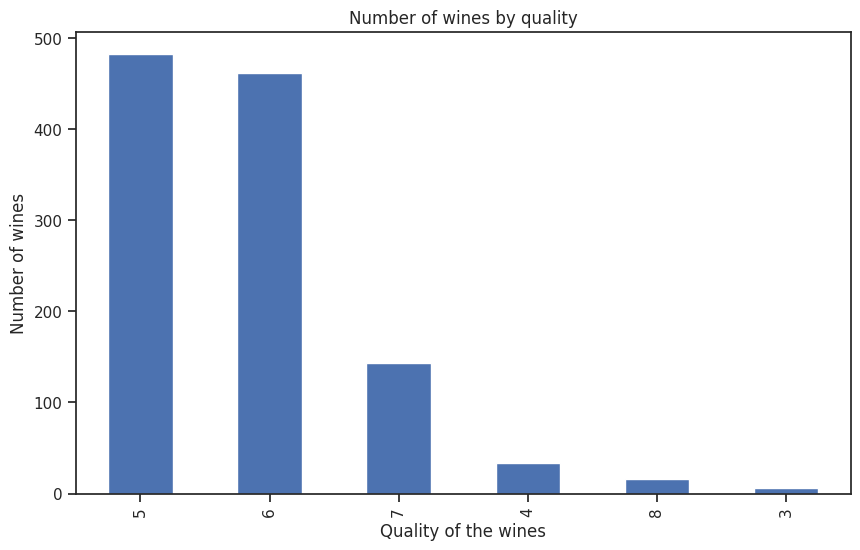

In [15]:
df.quality.value_counts().nlargest(30).plot(kind='bar', figsize=(10, 6))
plt.title("Number of wines by quality")
plt.ylabel('Number of wines')
plt.xlabel('Quality of the wines')
plt.show()



/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


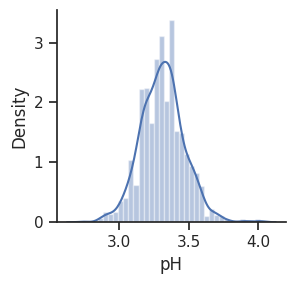

In [16]:
sns.FacetGrid(df).map(sns.distplot, "pH").add_legend()
plt.show()



/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


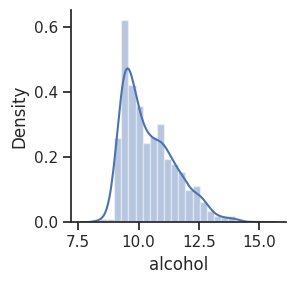

In [17]:
sns.FacetGrid(df).map(sns.distplot, "alcohol").add_legend()
plt.show()



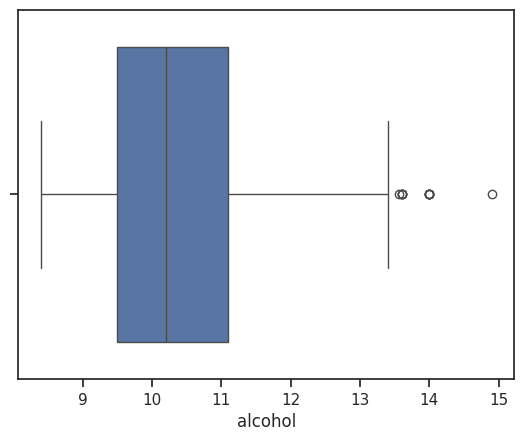

In [18]:
sns.boxplot(x="alcohol", data=df)
plt.show()



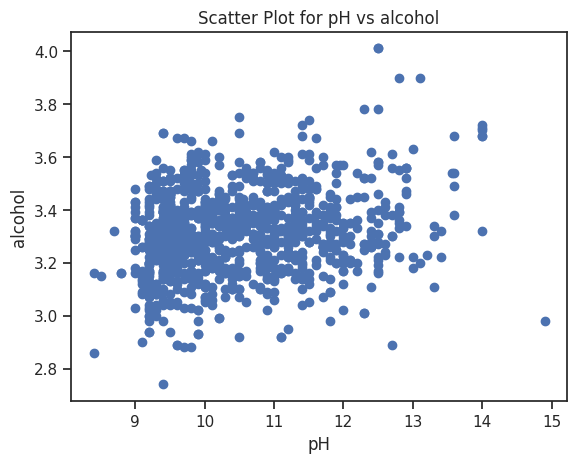

In [19]:
plt.scatter(df["alcohol"], df["pH"])
plt.title("Scatter Plot for pH vs alcohol")
plt.xlabel("pH")
plt.ylabel("alcohol")
plt.show()



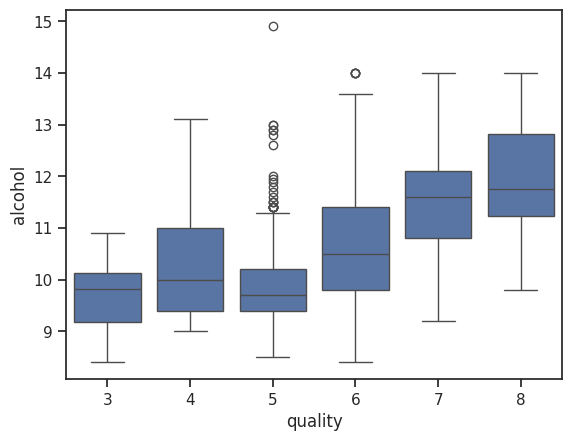

In [20]:
sns.boxplot(x="quality", y="alcohol", data=df)
plt.show()



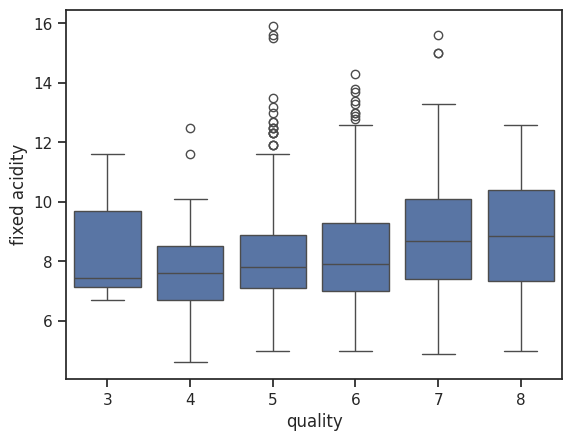

In [21]:
sns.boxplot(x="quality", y="fixed acidity", data=df)
plt.show()



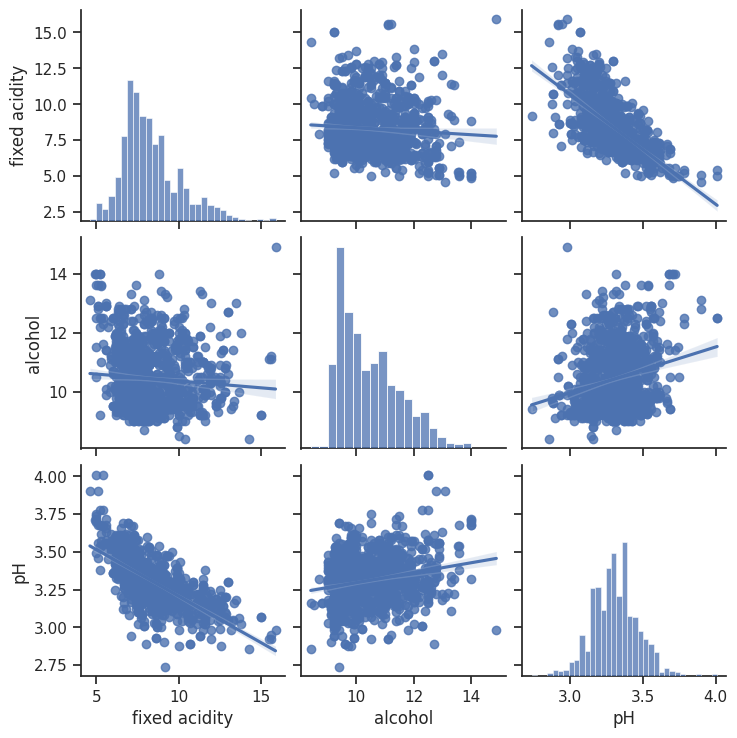

In [22]:
sns.pairplot(df, vars=['fixed acidity', 'alcohol', 'pH'], kind="reg")
plt.show()



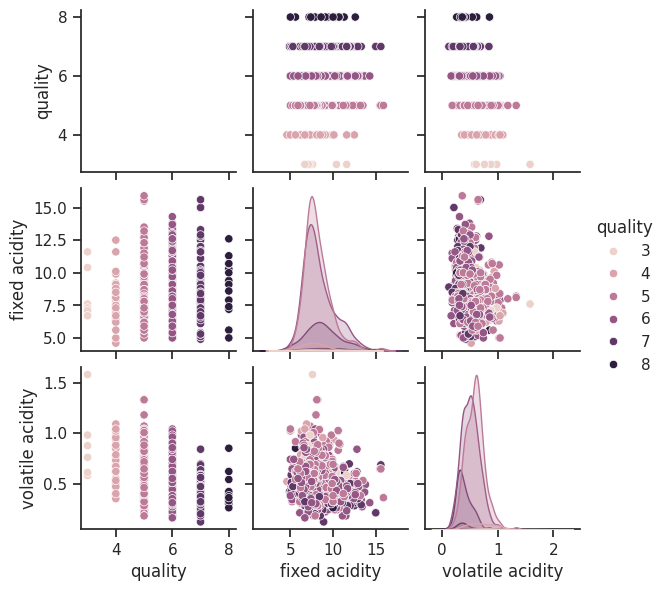

In [23]:
sns.set(style="ticks", color_codes=True)
sns.pairplot(df, height=2, vars=['quality', 'fixed acidity', 'volatile acidity'], hue="quality")
plt.show()



In [24]:
corr = stats.pearsonr(df["alcohol"], df["pH"])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])



p-value:	 1.2704383332771425e-14
cor:		 0.2253222028732469


In [25]:
correlation = df.corr(method='pearson', numeric_only=True)
print(correlation)



                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.250728     0.673157   
volatile acidity          -0.250728          1.000000    -0.544187   
citric acid                0.673157         -0.544187     1.000000   
residual sugar             0.171831         -0.005751     0.175815   
chlorides                  0.107889          0.056336     0.245312   
free sulfur dioxide       -0.164831         -0.001962    -0.057589   
total sulfur dioxide      -0.110628          0.077748     0.036871   
density                    0.681501          0.016512     0.375243   
pH                        -0.685163          0.221492    -0.546339   
sulphates                  0.174592         -0.276079     0.331232   
alcohol                   -0.075055         -0.203909     0.106250   
quality                    0.121970         -0.407394     0.240821   
Id                        -0.275826         -0.007892    -0.139011   

                   

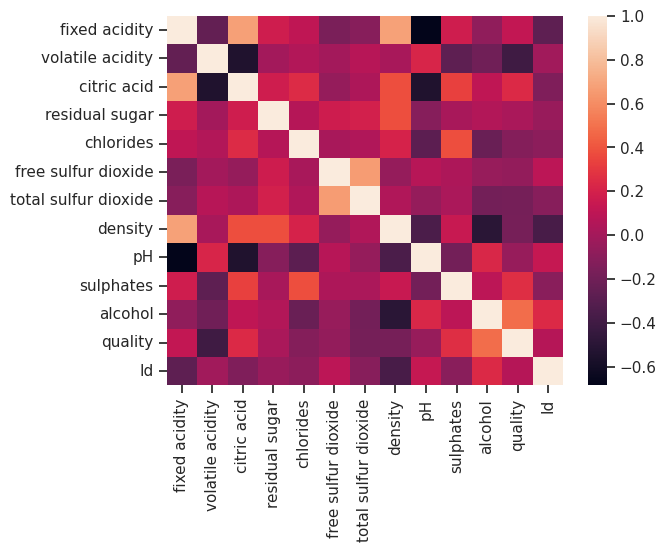

In [26]:
sns.heatmap(correlation, xticklabels=correlation.columns, yticklabels=correlation.columns)
plt.show()